# Séries temporais: dimensionar a operação

> **Dados integralmente sintéticos.** Execute `python -m src.pipeline` antes deste notebook.

Previsões de volume diário apoiam planejamento de capacidade. A comparação usa os mesmos três cortes com janela expansiva e horizonte fixo de 28 dias; nenhum ajuste consulta o futuro.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if not (root / "src").exists():
    root = root.parent
sys.path.insert(0, str(root))
import pandas as pd
from IPython.display import display, Image
from src.config import DATA, REPORTS, FIGURES


## Executar baseline, SARIMA e Prophet

In [2]:
from src.forecast import run
transactions = pd.read_parquet(DATA / 'transactions.parquet')
display(pd.DataFrame(run(transactions)))

C:\Users\jvbrg\Documents\Codex\2026-09-18\crie-do-zero-o-projeto-digital-4\work\clean-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


13:12:05 - cmdstanpy - INFO - Chain [1] start processing


13:12:05 - cmdstanpy - INFO - Chain [1] done processing


13:12:05 - cmdstanpy - INFO - Chain [1] start processing


13:12:05 - cmdstanpy - INFO - Chain [1] done processing


13:12:06 - cmdstanpy - INFO - Chain [1] start processing


13:12:06 - cmdstanpy - INFO - Chain [1] done processing


,model,mape,rmse
0,Prophet,4.611971,155.731094
1,Sazonal ingênuo,27.100179,823.227438
2,SARIMA,31.395090,926.354354


## Inspecionar estabilidade por janela e convergência

,model,fold,mape,rmse,converged
0,Sazonal ingênuo,1,31.537789,923.455622,True
1,SARIMA,1,40.283766,1128.104634,True
2,Prophet,1,4.279516,136.080820,True
3,Sazonal ingênuo,2,28.488474,850.035882,True
4,SARIMA,2,19.169206,605.939377,True
5,Prophet,2,5.836103,188.578691,True
6,Sazonal ingênuo,3,21.274275,696.190809,True
7,SARIMA,3,34.732299,1045.019051,True
8,Prophet,3,3.720294,142.533772,True


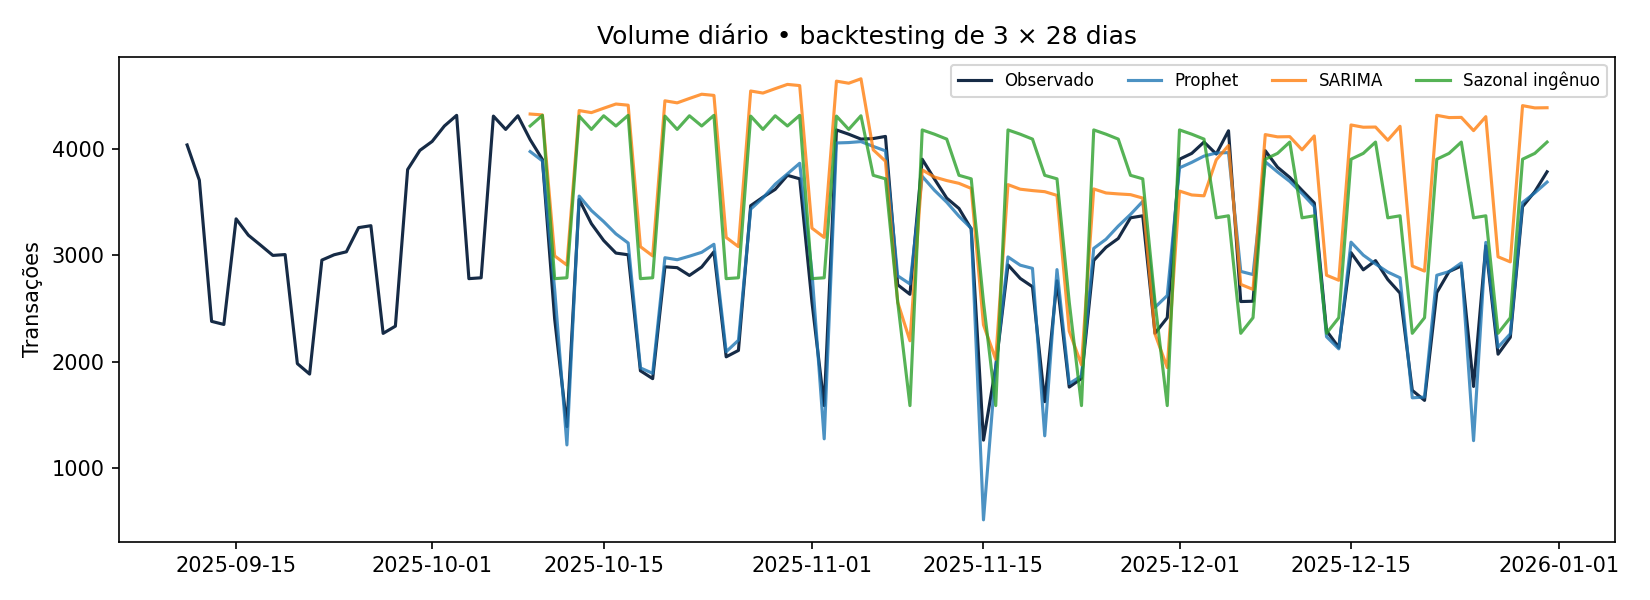

In [3]:
display(pd.read_csv(REPORTS / 'forecast_folds.csv'))
display(Image(filename=str(FIGURES / 'forecast.png')))

## STL descritivo semanal

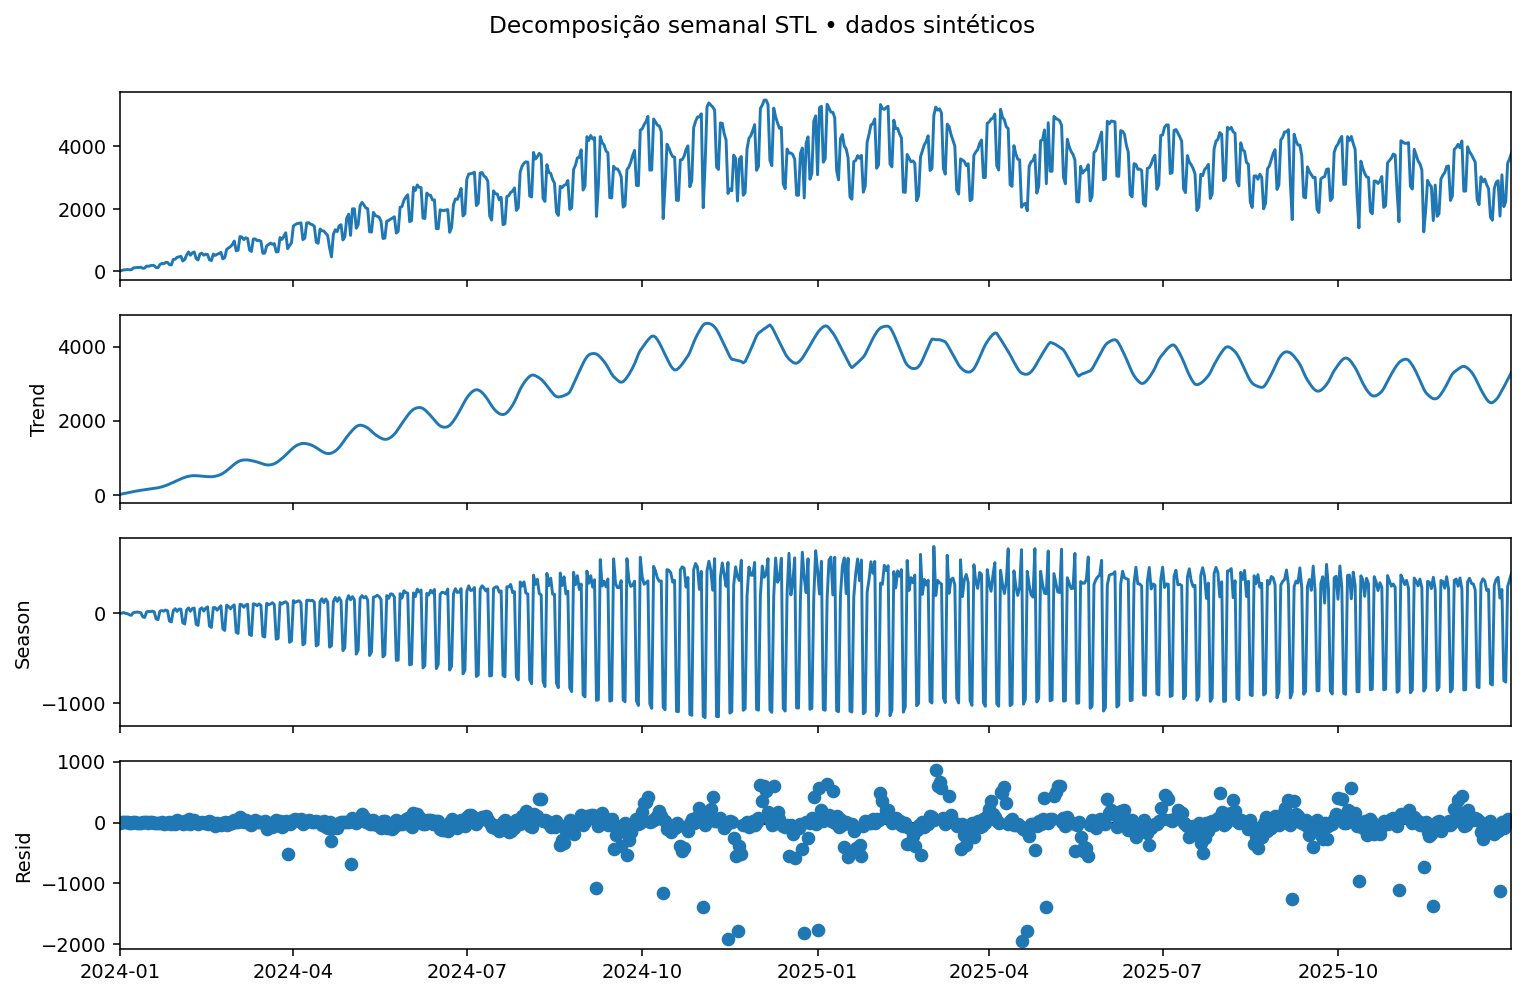

In [4]:
display(Image(filename=str(FIGURES / 'stl.png')))

## Leitura crítica

Baseline repete a última semana. SARIMA (1,1,1)(1,0,1,7) modela a sazonalidade semanal. Prophet adiciona ciclo mensal de 30,44 dias e feriados nacionais do Brasil. MAPE é percentual (denominador protegido em 1); RMSE está em transações/dia. STL completo é exploratório e não produz features de previsão. Há só três janelas de teste e não há prova de desempenho em um banco real.